# Exploring Linear and Ridge Regression with Cross-Validation
Dataset: Medical Cost Personal Dataset (Insurance.csv)

In [3]:

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score


In [4]:

# 2. Load Dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data = pd.read_csv(url)
data.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      3

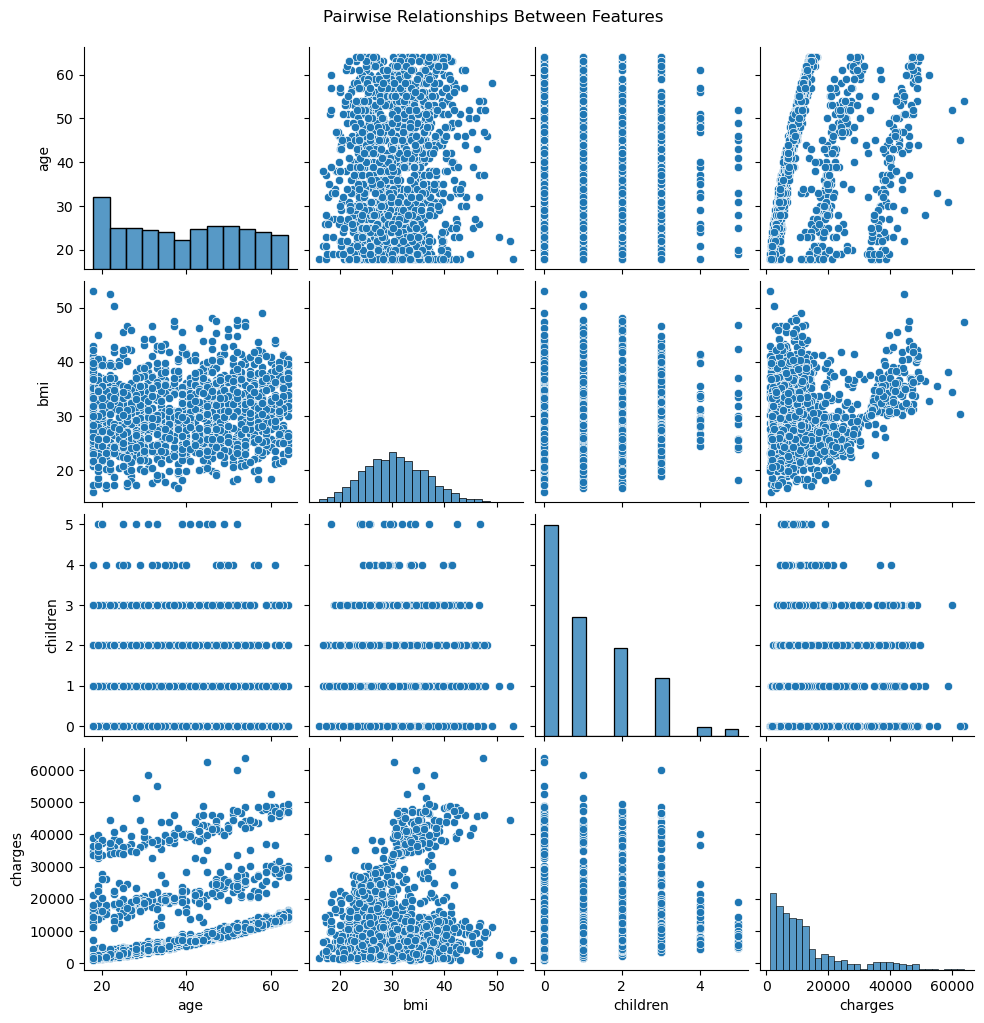

In [5]:

# 3. Dataset Overview
print(data.info())
print(data.isnull().sum())
print(data.describe())

sns.pairplot(data)
plt.suptitle("Pairwise Relationships Between Features", y=1.02)
plt.show()


In [6]:

# 4. Data Preprocessing
data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop("charges", axis=1)
y = data_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:

# 5. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MSE: {mse_lr:.2f}, R²: {r2_lr:.4f}")


Linear Regression MSE: 33596915.85, R²: 0.7836


In [8]:

# 6. Ridge Regression with Multiple Alphas
alphas = [0.01, 0.1, 1, 10, 100]
ridge_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred_ridge)
    r2 = r2_score(y_test, y_pred_ridge)
    ridge_results.append((alpha, mse, r2))

ridge_df = pd.DataFrame(ridge_results, columns=['Alpha', 'MSE', 'R²'])
ridge_df


,Alpha,MSE,R²
0,0.01,3.359700e+07,0.783592
1,0.10,3.359771e+07,0.783588
2,1.00,3.360497e+07,0.783541
3,10.00,3.368586e+07,0.783020
4,100.00,3.517630e+07,0.773420


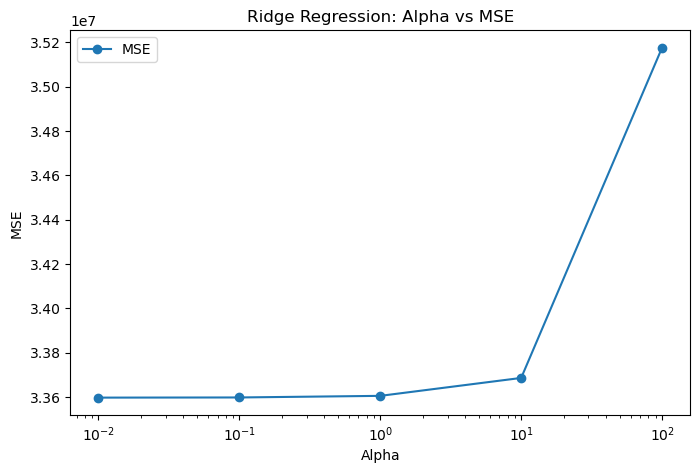

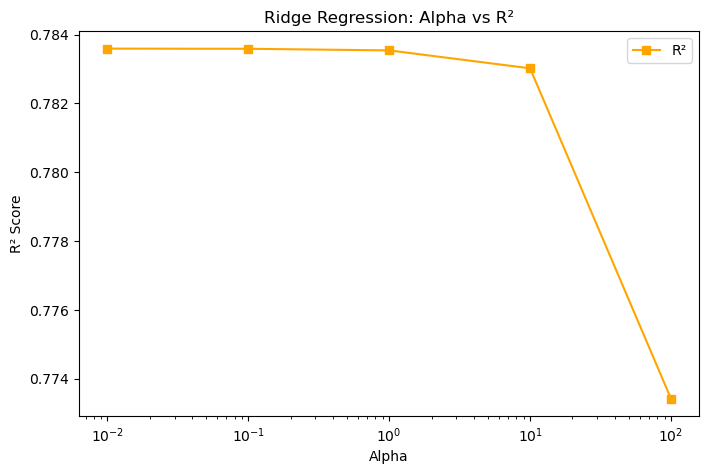

In [9]:

# 7. Visualization
plt.figure(figsize=(8,5))
plt.plot(ridge_df['Alpha'], ridge_df['MSE'], marker='o', label='MSE')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Ridge Regression: Alpha vs MSE')
plt.xscale('log')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(ridge_df['Alpha'], ridge_df['R²'], marker='s', color='orange', label='R²')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('Ridge Regression: Alpha vs R²')
plt.xscale('log')
plt.legend()
plt.show()


In [10]:

# 8. Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')
cv_scores_ridge = cross_val_score(Ridge(alpha=1), X, y, cv=kf, scoring='r2')

print(f"Linear Regression CV Mean R²: {cv_scores_lr.mean():.4f}")
print(f"Ridge Regression CV Mean R²: {cv_scores_ridge.mean():.4f}")


Linear Regression CV Mean R²: 0.7402
Ridge Regression CV Mean R²: 0.7403


In [11]:

# 9. Ridge GridSearchCV
ridge = Ridge()
params = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(ridge, params, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)

best_alpha = grid.best_params_['alpha']
best_ridge = grid.best_estimator_
y_pred_best = best_ridge.predict(X_test_scaled)

mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Best Alpha: {best_alpha}, MSE: {mse_best:.2f}, R²: {r2_best:.4f}")


Best Alpha: 10, MSE: 33685862.86, R²: 0.7830


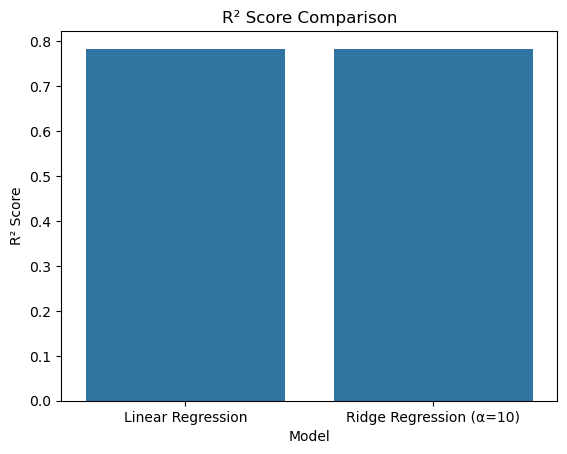

In [12]:

# 10. Model Comparison Summary
comparison = pd.DataFrame({
    "Model": ["Linear Regression", f"Ridge Regression (α={best_alpha})"],
    "MSE": [mse_lr, mse_best],
    "R² Score": [r2_lr, r2_best]
})
comparison

sns.barplot(data=comparison, x="Model", y="R² Score")
plt.title("R² Score Comparison")
plt.show()



# Key Insights
- Linear Regression can overfit due to multicollinearity.
- Ridge Regression reduces variance via coefficient shrinkage.
- Cross-validation confirms Ridge provides more consistent performance.
- Alpha tuning balances bias-variance tradeoff effectively.
